# Dataset Validation : Baseline

To validate found public datasets, there are multiple things that must me verified.

* Does the dataset contain the necessary columns? ( light, soil moisture, humidity, ambient temperature, and plant health)
* Does the dataset contains missing values?
* What are the data types?
* Are there any duplicate rows?
* Is the dataset balanced?

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = pd.read_csv("../datasets/plant_health_data.csv")
data.sample(5)

feature_columns = [
    # 'Light_Intensity',
    'Soil_Moisture',
    'Humidity',
    'Ambient_Temperature'
]

target_column = 'Plant_Health_Status'

required_columns = feature_columns + [target_column]

missing_columns = [col for col in required_columns if col not in data.columns]

if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
print(data[required_columns].dtypes)

print("\nMissing values per required column:")
print(data[required_columns].isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())

Dataset shape: (1200, 14)

Column names:
['Timestamp', 'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal', 'Plant_Health_Status']

Data types:
Soil_Moisture          float64
Humidity               float64
Ambient_Temperature    float64
Plant_Health_Status        str
dtype: object

Missing values per required column:
Soil_Moisture          0
Humidity               0
Ambient_Temperature    0
Plant_Health_Status    0
dtype: int64

Duplicate rows: 0


In [31]:
dataset = data[required_columns].copy()
dataset = dataset.dropna()

print("\nShape after dropping missing values:", dataset.shape)

dataset.sample(5)


Shape after dropping missing values: (1200, 4)


,Soil_Moisture,Humidity,Ambient_Temperature,Plant_Health_Status
984,28.965386,53.572187,25.069378,Moderate Stress
4,39.822216,63.772036,28.929001,High Stress
679,26.744091,61.522743,20.303201,Moderate Stress
1099,38.031926,55.994689,21.029931,Healthy
1156,38.285280,57.924654,23.788241,Moderate Stress



Target class distribution:
Plant_Health_Status
High Stress        500
Moderate Stress    401
Healthy            299
Name: count, dtype: int64


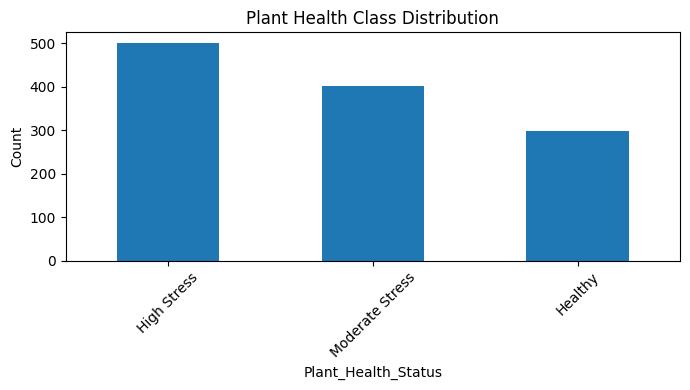

In [32]:
print("\nTarget class distribution:")
print(dataset[target_column].value_counts())

dataset[target_column].value_counts().plot(kind='bar', figsize=(7, 4))
plt.title("Plant Health Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
x = dataset[feature_columns]
y = dataset[target_column]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.825


In [34]:
print("Train set report:")
train_predictions = model.predict(x_train)
print(classification_report(y_train, train_predictions))

print("Test set report:")
test_predictions = model.predict(x_test)
print(classification_report(y_test, test_predictions))

Train set report:
                 precision    recall  f1-score   support

        Healthy       1.00      1.00      1.00       239
    High Stress       1.00      1.00      1.00       400
Moderate Stress       1.00      1.00      1.00       321

       accuracy                           1.00       960
      macro avg       1.00      1.00      1.00       960
   weighted avg       1.00      1.00      1.00       960

Test set report:
                 precision    recall  f1-score   support

        Healthy       0.71      0.92      0.80        60
    High Stress       0.96      0.73      0.83       100
Moderate Stress       0.80      0.88      0.84        80

       accuracy                           0.82       240
      macro avg       0.83      0.84      0.82       240
   weighted avg       0.85      0.82      0.83       240



<Figure size 600x600 with 0 Axes>

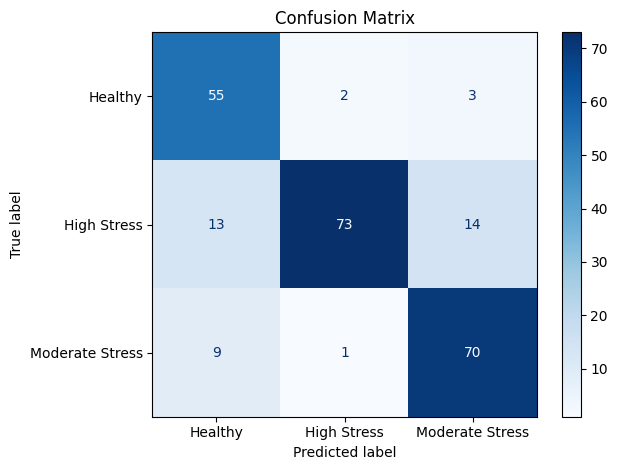

In [35]:
class_labels = sorted(y.unique())

cm = confusion_matrix(y_test, test_predictions, labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

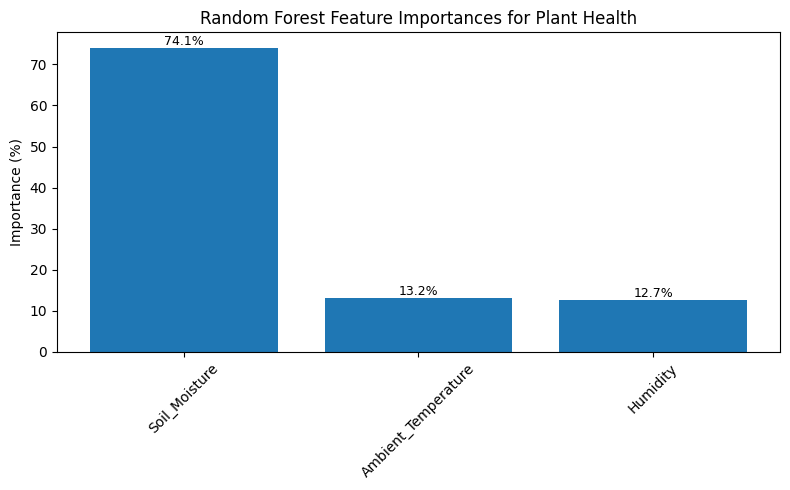

In [36]:
importances = model.feature_importances_
feature_names = x.columns
importances_pct = importances * 100

indices = np.argsort(importances_pct)[::-1]

plt.figure(figsize=(8, 5))
bars = plt.bar(range(len(importances_pct)), importances_pct[indices])

plt.xticks(
    range(len(importances_pct)),
    feature_names[indices],
    rotation=45
)

plt.ylabel("Importance (%)")
plt.title("Random Forest Feature Importances for Plant Health")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [37]:
print("Dataset Validation Summary")
print("--------------------------")
print(f"Rows used: {len(dataset)}")
print(f"Features used: {feature_columns}")
print(f"Target classes: {sorted(y.unique().tolist())}")
print(f"Missing values removed: {data[required_columns].isnull().any(axis=1).sum()}")
print(f"Duplicate rows in original data: {data.duplicated().sum()}")
print(f"Test accuracy: {accuracy_score(y_test, test_predictions):.4f}")

Dataset Validation Summary
--------------------------
Rows used: 1200
Features used: ['Soil_Moisture', 'Humidity', 'Ambient_Temperature']
Target classes: ['Healthy', 'High Stress', 'Moderate Stress']
Missing values removed: 0
Duplicate rows in original data: 0
Test accuracy: 0.8250


## Validation Conclusion

This dataset appears usable for plant health classification based on light intensity,
soil moisture, humidity, and ambient temperature.

Points checked:

- Required columns are present
- Missing values were handled
- Class distribution was inspected
- Baseline Random Forest performance was evaluated
- Confusion matrix and classification report were reviewed
- Feature importance was analyzed

Note:
This validates the dataset as a machine learning candidate, but not yet as an ESP32 deployment model.
For ESP32, additional validation is needed for:

- model size
- RAM usage
- inference speed
- robustness to noisy sensor values